# Entertainment Analytics - Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
netflix = pd.read_csv("../data/cleaned/netflix_cleaned.csv")
spotify = pd.read_csv("../data/cleaned/spotify_cleaned.csv")

In [5]:
print(netflix.shape)
print(spotify.shape)

(8807, 12)
(113550, 20)


## 3. Netflix Content Type Analysis

In [4]:
netflix["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [5]:
netflix["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

## 4. Netflix Genre Analysis

In [ ]:
netflix["listed_in"].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [6]:
genres = netflix["listed_in"].str.split(", ")
genre_counts = genres.explode().value_counts()

In [7]:
genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

## 5. Netflix Content by Release Year

In [17]:
year_counts = netflix["release_year"].value_counts().sort_index()
year_counts.tail(10)

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

## 6. Netflix Rating Analysis

In [18]:
netflix["rating"].value_counts().head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

## 7. Spotify Popularity Analysis

In [19]:
spotify["popularity"].describe()

count    113550.000000
mean         33.324139
std          22.283976
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [20]:
spotify["popularity"].mean()

np.float64(33.32413914575077)

## 8. Spotify Genre Analysis

In [21]:
spotify["track_genre"].value_counts().head(10)

track_genre
acoustic      1000
british       1000
country       1000
disco         1000
electronic    1000
emo           1000
funk          1000
garage        1000
indie-pop     1000
industrial    1000
Name: count, dtype: int64

In [5]:
genre_popularity = spotify.groupby("track_genre")["popularity"].mean().sort_values(ascending=False)

In [23]:
genre_popularity.head(10)

track_genre
pop-film     59.280280
k-pop        56.906907
chill        53.704705
sad          52.379000
grunge       49.582583
indian       49.528529
anime        48.766767
emo          48.128000
pop          47.903323
sertanejo    47.866000
Name: popularity, dtype: float64

## 9. Spotify Audio Feature Analysis

In [24]:
spotify[["danceability", "energy", "valence", "acousticness"]].mean()

danceability    0.567031
energy          0.642090
valence         0.474207
acousticness    0.314067
dtype: float64

## 10. Netflix Movies vs TV Shows

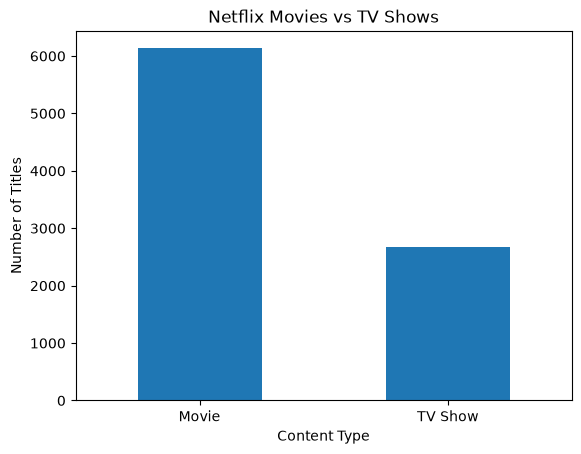

In [27]:
type_counts = netflix["type"].value_counts()

type_counts.plot(kind="bar")

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

## 11. Netflix Content Release Trend

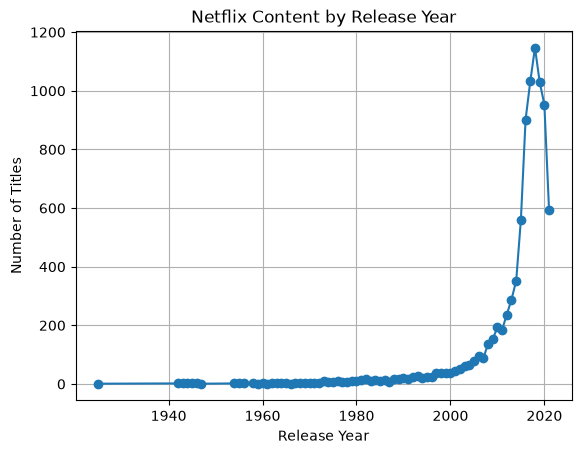

In [28]:
year_counts.plot(kind="line", marker="o")

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

## 12. Top 10 Netflix Genres

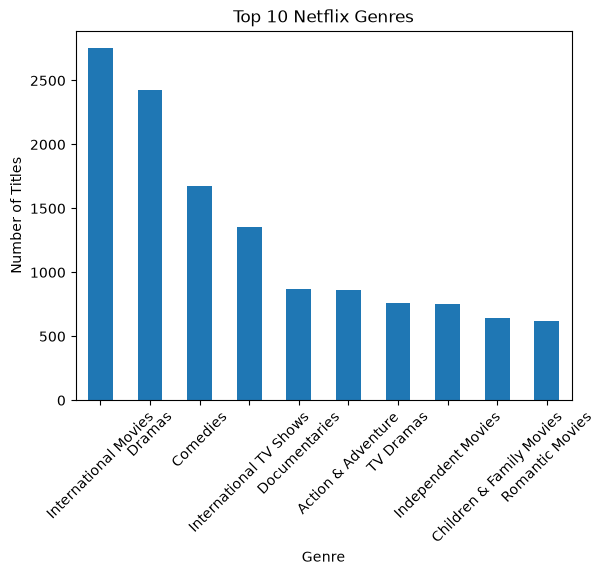

In [9]:
genre_counts.head(10).plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

## 13. Top 10 Spotify Genres by Popularity

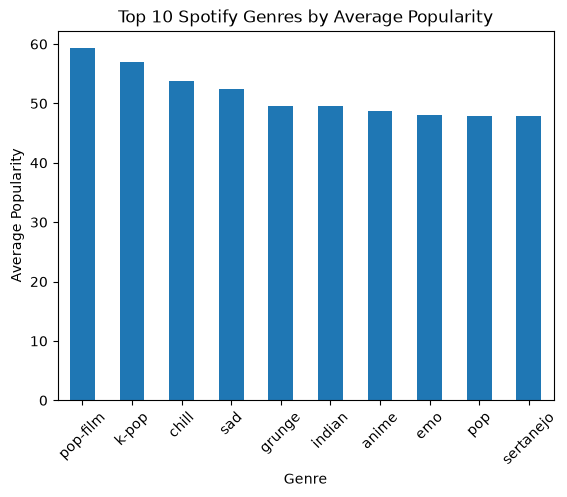

In [12]:
top_genres = genre_popularity.head(10)

top_genres.plot(kind="bar")

plt.title("Top 10 Spotify Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.show()

## 14. Spotify Audio Features

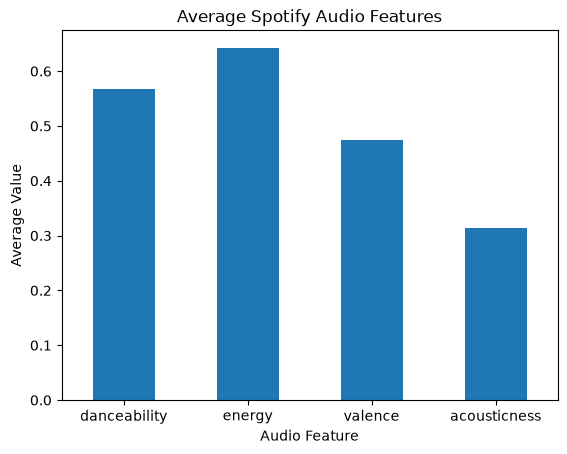

In [13]:
audio_features = spotify[[
    "danceability",
    "energy",
    "valence",
    "acousticness"
]].mean()

audio_features.plot(kind="bar")

plt.title("Average Spotify Audio Features")
plt.xlabel("Audio Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

## 15. EDA Summary

### Netflix
- Movies make up approximately 69.6% of the Netflix catalog.
- TV Shows make up approximately 30.4%.
- International Movies and Dramas are the most common genres.
- 2018 had the highest number of titles by release year in the analyzed period.
- TV-MA is the most common rating.

### Spotify
- The average track popularity is approximately 33.32 out of 100.
- Each genre contains approximately 1,000 tracks in this dataset.
- Pop-film has the highest average popularity, followed by K-pop.
- Energy and danceability have relatively higher average values among the selected audio features.

## 16. Netflix Content by Rating

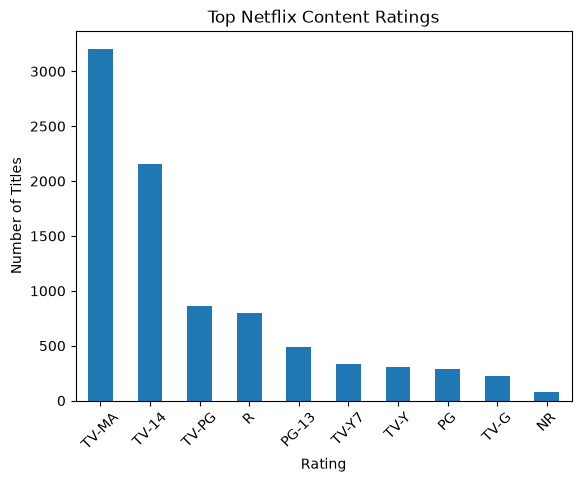

In [3]:
rating_counts = netflix["rating"].value_counts().head(10)

rating_counts.plot(kind="bar")

plt.title("Top Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [6]:
genre_popularity.head(10)

track_genre
pop-film     59.280280
k-pop        56.906907
chill        53.704705
sad          52.379000
grunge       49.582583
indian       49.528529
anime        48.766767
emo          48.128000
pop          47.903323
sertanejo    47.866000
Name: popularity, dtype: float64

## 17. Top 10 Spotify Genres by Average Popularity

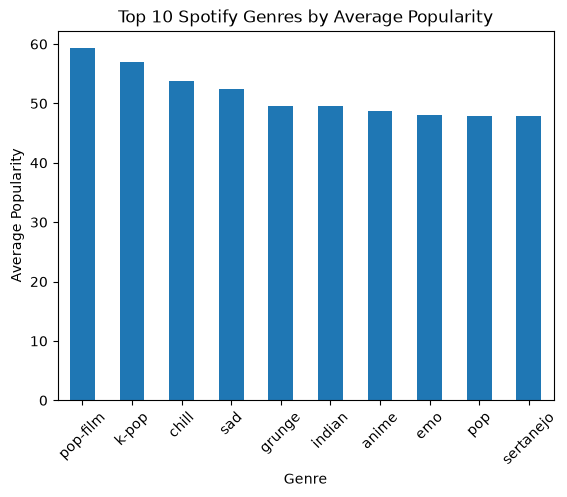

In [7]:
top_genres = genre_popularity.head(10)

top_genres.plot(kind="bar")

plt.title("Top 10 Spotify Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.show()

## 18. Spotify Popularity Distribution

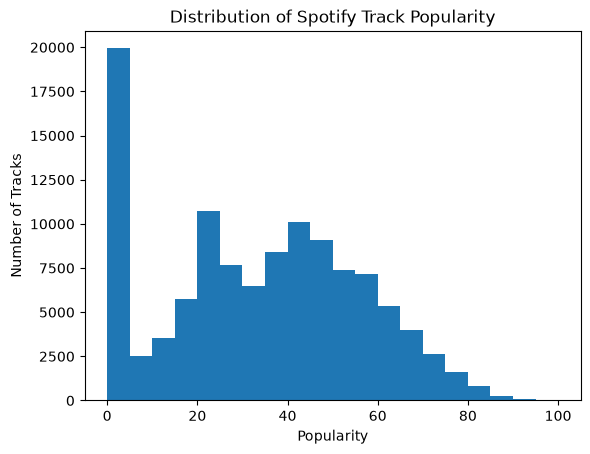

In [8]:
spotify["popularity"].plot(kind="hist", bins=20)

plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.show()

## 19. Popularity vs Energy

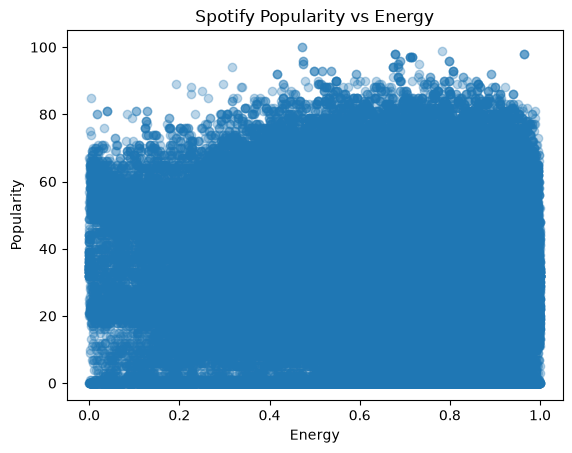

In [9]:
plt.scatter(spotify["energy"], spotify["popularity"], alpha=0.3)

plt.title("Spotify Popularity vs Energy")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.show()

## 20. Popularity vs Danceability

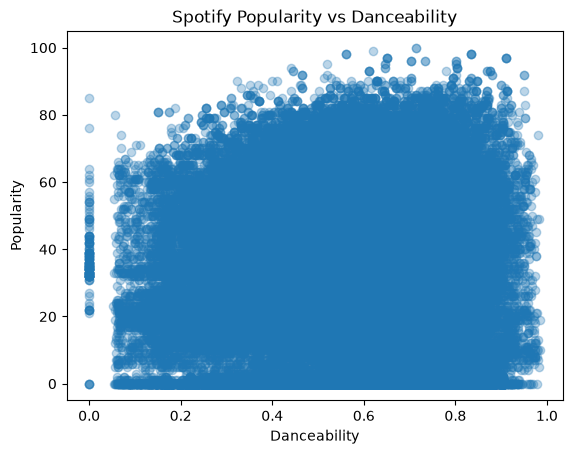

In [10]:
plt.scatter(spotify["danceability"], spotify["popularity"], alpha=0.3)

plt.title("Spotify Popularity vs Danceability")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.show()

In [11]:

spotify[[
    "popularity",
    "danceability",
    "energy",
    "valence",
    "acousticness"
]].corr()["popularity"].sort_values(ascending=False)

popularity      1.000000
danceability    0.034412
energy         -0.002444
acousticness   -0.022370
valence        -0.041109
Name: popularity, dtype: float64